In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [5]:
import pandas as pd

df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.shape

(200, 5)

In [8]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [9]:
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


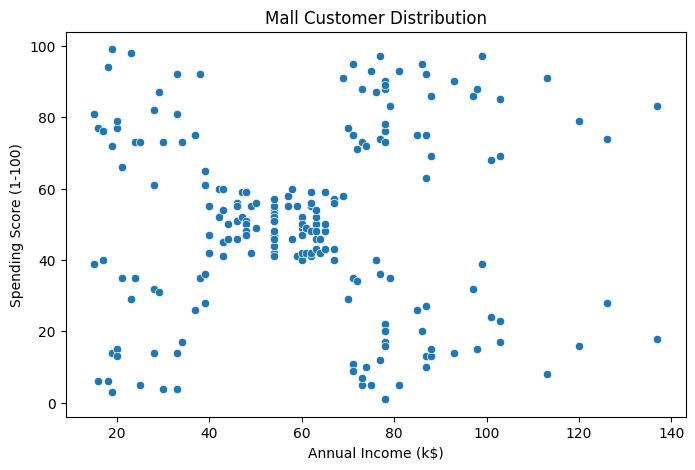

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Mall Customer Distribution")
plt.show()

In [12]:
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [14]:
X_scaled[:5]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298],
       [-1.13750203, -1.70082976,  1.04041783],
       [-0.56336851, -1.66266033, -0.39597992]])

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

labels = kmeans.fit_predict(X_scaled)

labels

array([1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 4, 1, 0, 1,
       0, 1, 4, 1, 1, 1, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 4, 1,
       4, 4, 1, 1, 4, 4, 4, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1, 4, 4, 1,
       1, 4, 4, 1, 4, 4, 1, 1, 4, 1, 4, 1, 1, 4, 4, 1, 4, 1, 4, 4, 4, 4,
       4, 1, 3, 1, 1, 1, 4, 4, 4, 4, 1, 3, 2, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 4, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2,
       3, 2], dtype=int32)

In [16]:
df['Cluster'] = labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,1
4,5,Female,31,17,40,1


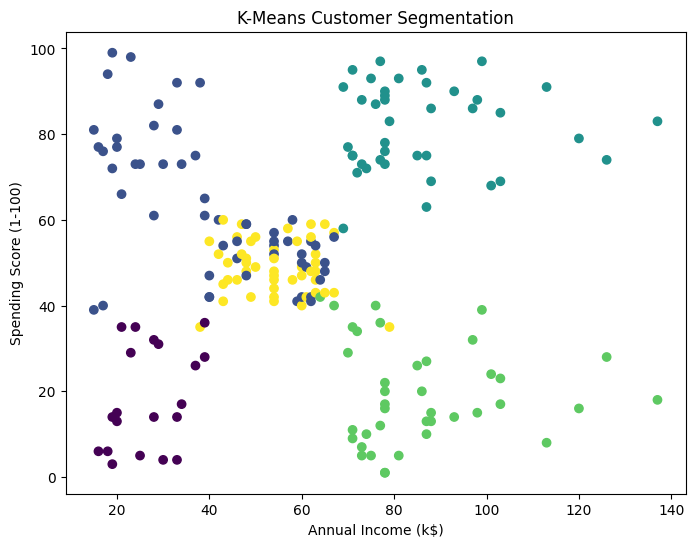

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("K-Means Customer Segmentation")

plt.show()

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

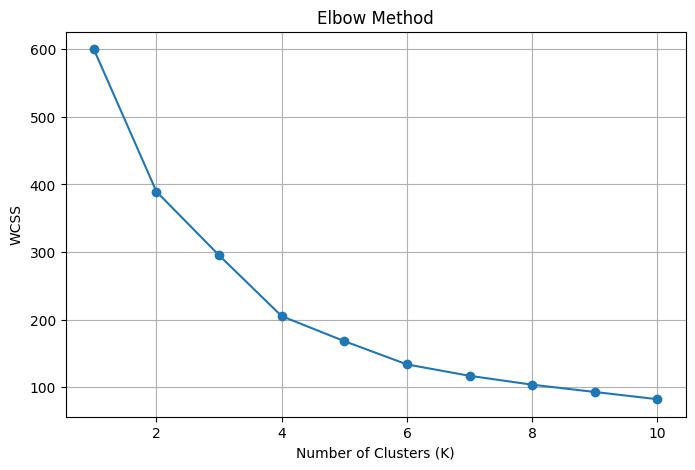

In [19]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

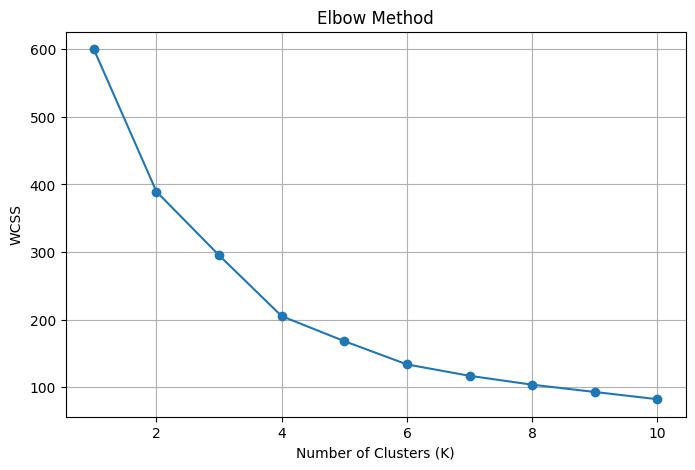

In [20]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.savefig("elbow_plot.png")

plt.show()

In [21]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    scores.append(score)

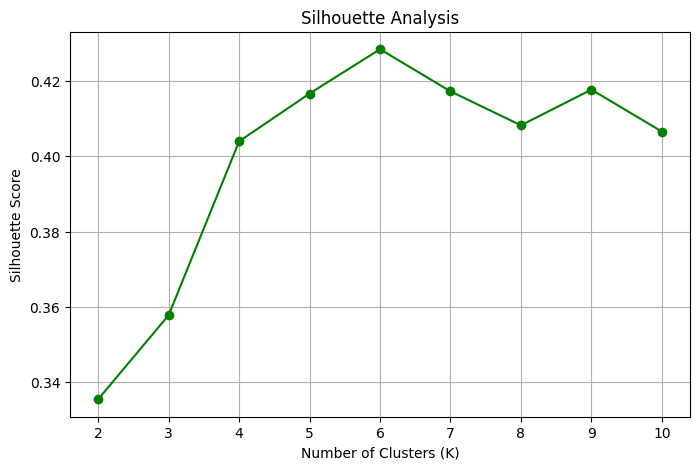

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o', color='green')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.show()

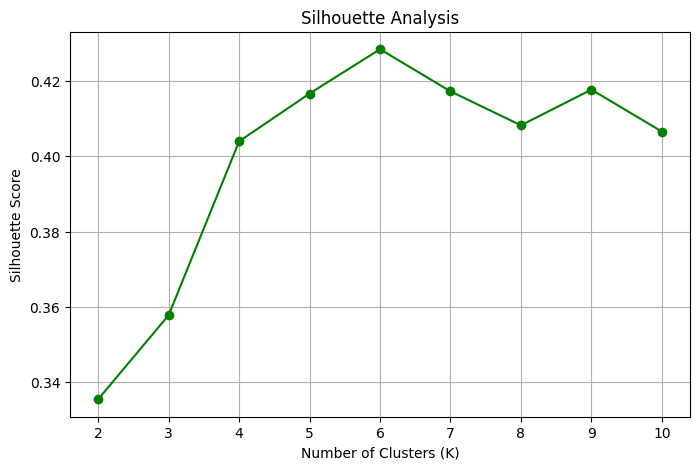

In [23]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), scores, marker='o', color='green')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.grid(True)

plt.savefig("silhouette_plot.png")

plt.show()

In [24]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

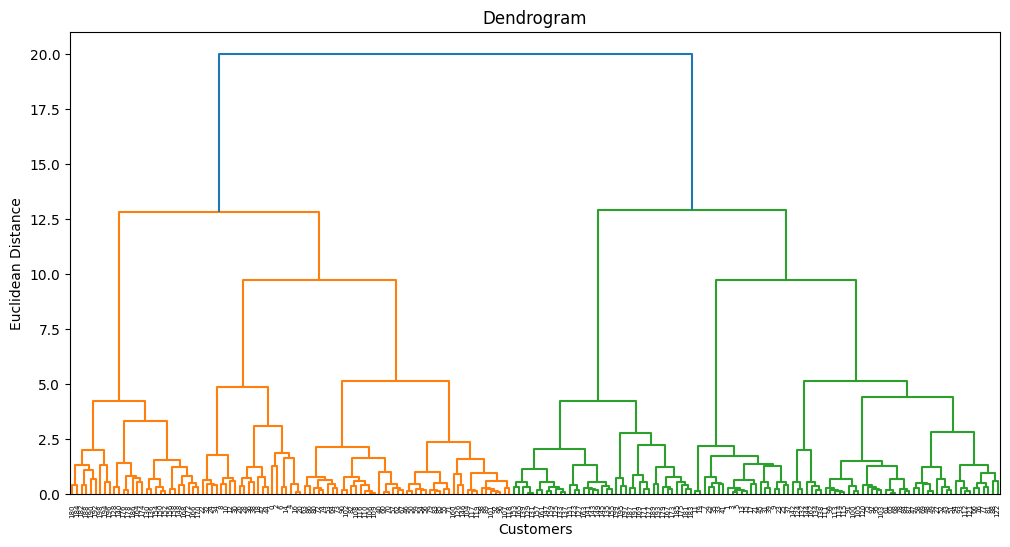

In [25]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [26]:
from scipy.cluster.hierarchy import linkage, dendrogram
import matplotlib.pyplot as plt

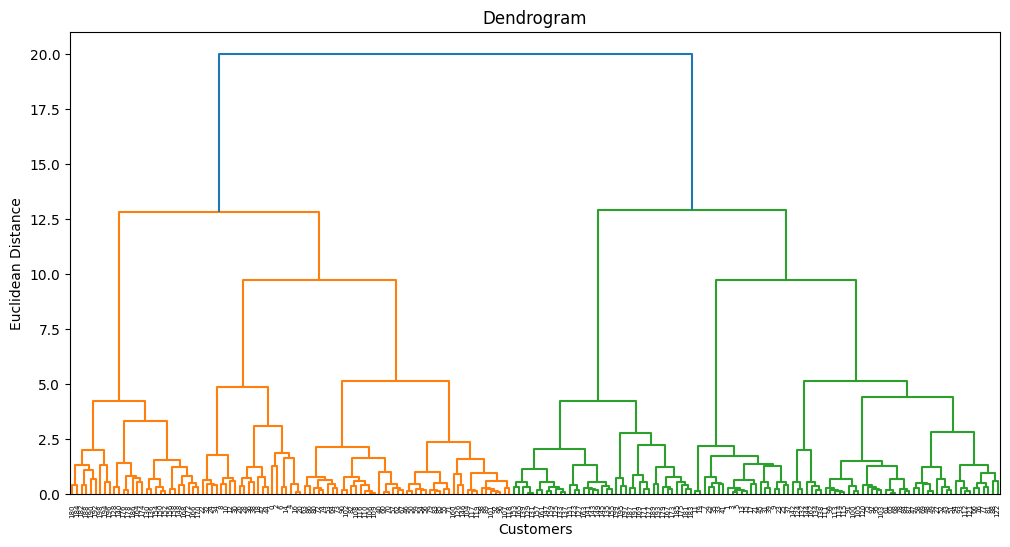

In [27]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

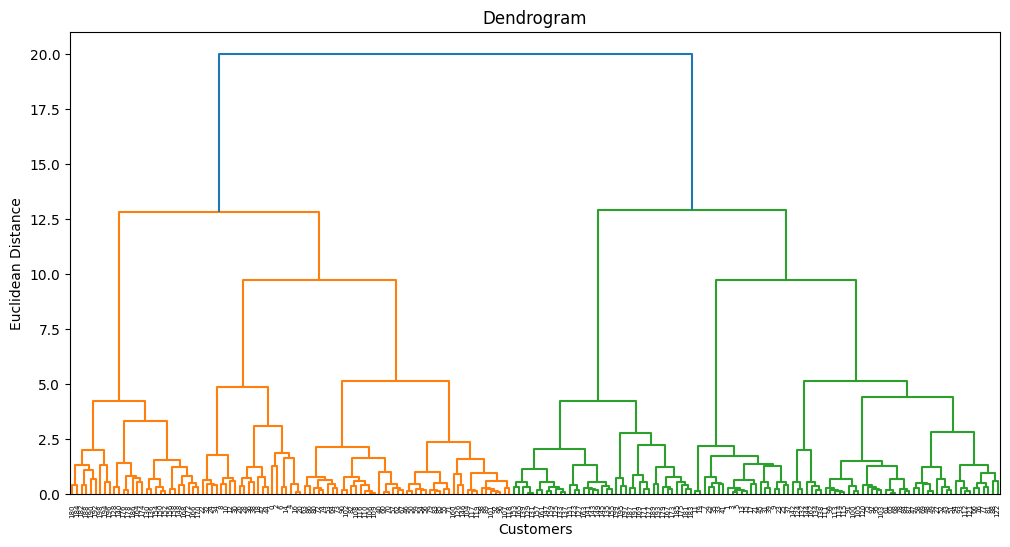

In [28]:
plt.figure(figsize=(12,6))

dendrogram(linked)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.savefig("dendrogram.png")

plt.show()

In [29]:
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(
    n_clusters=5
)

hc_labels = hc.fit_predict(X_scaled)

In [30]:
df["HC_Cluster"] = hc_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,HC_Cluster
0,1,Male,19,15,39,1,4
1,2,Male,21,15,81,1,0
2,3,Female,20,16,6,0,4
3,4,Female,23,16,77,1,0
4,5,Female,31,17,40,1,4


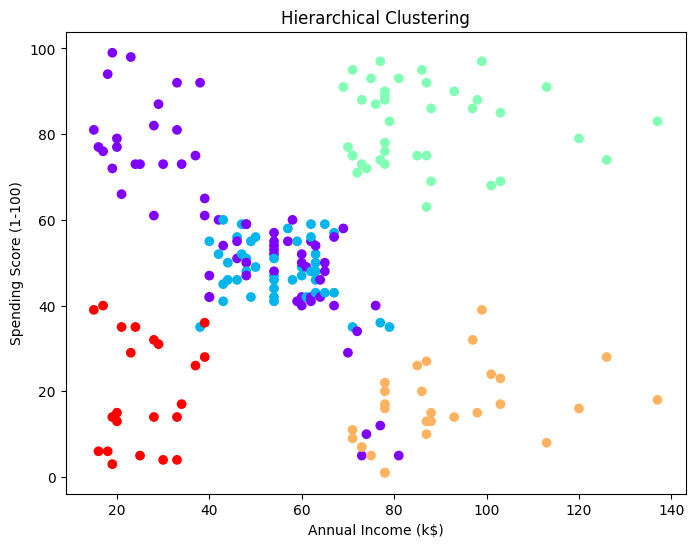

In [31]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["HC_Cluster"],
    cmap="rainbow"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")

plt.show()

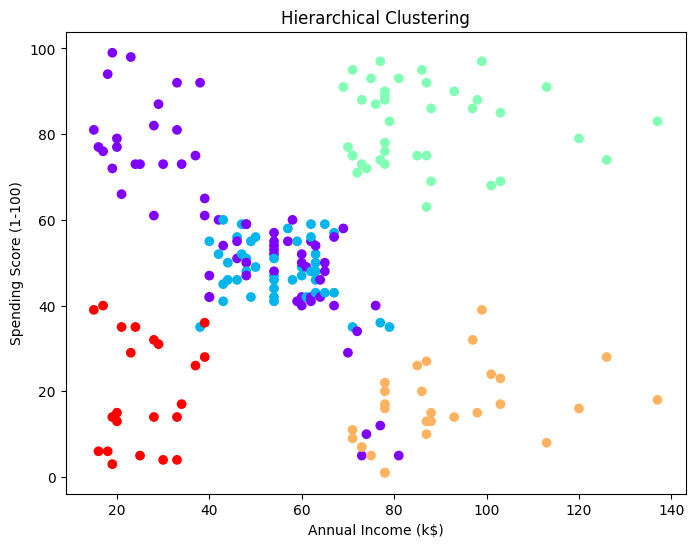

In [32]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["HC_Cluster"],
    cmap="rainbow"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Hierarchical Clustering")

plt.savefig("hierarchical_clusters.png")

plt.show()

In [33]:
from sklearn.cluster import DBSCAN

In [34]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

dbscan_labels = dbscan.fit_predict(X_scaled)

In [35]:
df["DBSCAN_Cluster"] = dbscan_labels

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,HC_Cluster,DBSCAN_Cluster
0,1,Male,19,15,39,1,4,-1
1,2,Male,21,15,81,1,0,0
2,3,Female,20,16,6,0,4,-1
3,4,Female,23,16,77,1,0,0
4,5,Female,31,17,40,1,4,0


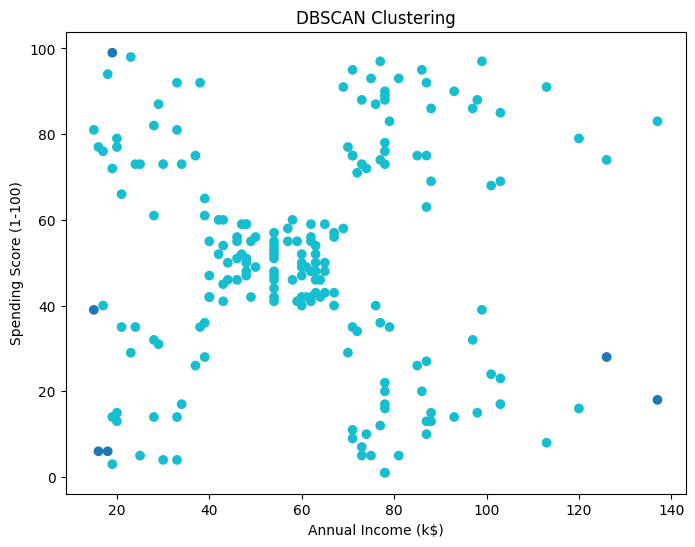

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["DBSCAN_Cluster"],
    cmap="tab10"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")

plt.show()

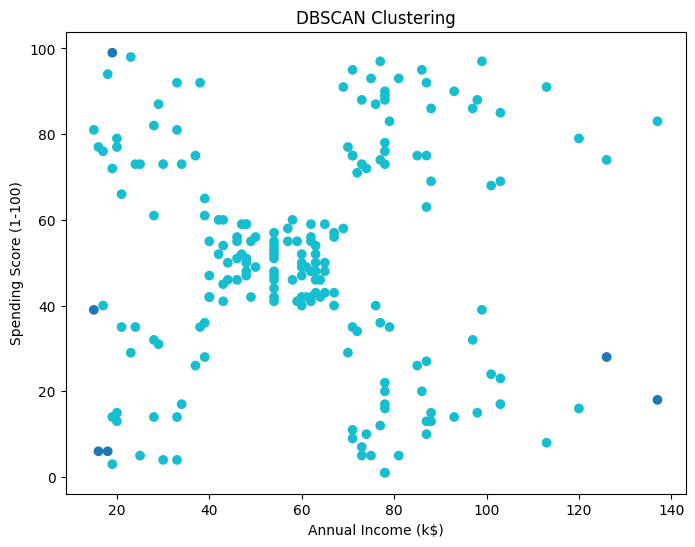

In [37]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Annual Income (k$)"],
    df["Spending Score (1-100)"],
    c=df["DBSCAN_Cluster"],
    cmap="tab10"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("DBSCAN Clustering")

plt.savefig("dbscan_clusters.png")

plt.show()

In [38]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

In [39]:
kmeans_sil = silhouette_score(X_scaled, labels)
kmeans_db = davies_bouldin_score(X_scaled, labels)

print("K-Means")
print("Silhouette Score:", kmeans_sil)
print("Davies-Bouldin Index:", kmeans_db)

K-Means
Silhouette Score: 0.40655411010117015
Davies-Bouldin Index: 0.8679043654208403


In [40]:
hc_sil = silhouette_score(X_scaled, hc_labels)
hc_db = davies_bouldin_score(X_scaled, hc_labels)

print("Hierarchical Clustering")
print("Silhouette Score:", hc_sil)
print("Davies-Bouldin Index:", hc_db)

Hierarchical Clustering
Silhouette Score: 0.39002826186267214
Davies-Bouldin Index: 0.9162886109753661


In [45]:
dbscan = DBSCAN(eps=0.7, min_samples=3)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [46]:
mask = dbscan_labels != -1

dbscan_sil = silhouette_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

dbscan_db = davies_bouldin_score(
    X_scaled[mask],
    dbscan_labels[mask]
)

print("DBSCAN")
print("Silhouette Score:", dbscan_sil)
print("Davies-Bouldin Index:", dbscan_db)

DBSCAN
Silhouette Score: 0.1703122548132622
Davies-Bouldin Index: 0.8062574140682905


In [47]:
comparison = {
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Silhouette Score": [kmeans_sil, hc_sil, dbscan_sil],
    "Davies-Bouldin Index": [kmeans_db, hc_db, dbscan_db]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Algorithm,Silhouette Score,Davies-Bouldin Index
0,K-Means,0.406554,0.867904
1,Hierarchical,0.390028,0.916289
2,DBSCAN,0.170312,0.806257


In [48]:
df.to_csv("Mall_Customers_Clustered.csv", index=False)

print("Dataset saved successfully!")

Dataset saved successfully!
